In [1]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) 

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime

In [3]:
import glob
import os

### Read stats 

In [4]:
main_dir = '/pscratch/sd/p/paccini/temp/hackathon/updated_environmental_variables/'
mcs_stats = 'df_filtered_mcs_track_ids/'
# main_dir = '/Users/pacc275/local_documents/hackathon/updated_environmental_variables/' #local
# --- Define main components ---
TRACK_MODELS = ['um', 'icon', 'scream', 'ifs', 'nicam', 'obs', 'obs_v7'] 
VARIABLES = ['prw', 'rh500', 'rh850', 'q500', 'q850', 'omega500', 'omega850',  'lShear', 'dShear','free_rh'] #'w850', 'w500',
CRITERIA = ['all', 'min2']

In [11]:
# --- Path Configuration ---

# 1. Map your track model name (e.g., 'obs') to the 
#    corresponding environmental data directory (e.g., 'era5')
ENV_MODEL_DIR_MAP = {
    'um': 'UM_all',
    'icon': 'ICON_all',
    'scream': 'SCREAM_all',
    'ifs': 'IFS_all',
    'nicam': 'NICAM_all',
    'obs_v7': 'ERA5_IMERGv7_all' ,
    'obs': 'era5'  # Key insight: 'obs' tracks map to 'era5' env data
}

# 2. Define the path pattern for each variable. 
VAR_PATH_PATTERNS = {
    # Default patterns used by most models (um, scream, etc.)
    'default': {
        'prw':      {'type': 'dir', 'pattern': 'prw/'},
        'rh500':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_500hPa.parquet'},
        'rh850':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_850hPa.parquet'},
        'free_rh':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_avg850-*-500hPa.parquet'},
        'q500':     {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_500hPa.parquet'},
        'q850':     {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_850hPa.parquet'},
        'omega500': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_500hPa.parquet'},
        'omega850': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_850hPa.parquet'},
        # 'w500':     {'type': 'glob', 'pattern': 'wa/mcs_env_wa_*_wa_500hPa.parquet'},
        # 'w850':     {'type': 'glob', 'pattern': 'wa/mcs_env_wa_*_wa_850hPa.parquet'},
         'lShear':   {'type': 'dir', 'pattern': 'low_shear_magnitude_975hPa-800hPa/'},
        'dShear':   {'type': 'dir', 'pattern': 'deep_shear_magnitude_850hPa-400hPa/'},
    },
    # Overrides for the 'obs' (era5) model
    'obs': {
        'q500':     {'type': 'dir', 'pattern': 'q_500mb/'},
         'rh500':  {'type': 'dir', 'pattern': 'rh_500mb/'},
        'q850':     {'type': 'dir', 'pattern': 'q_850mb/'},
         'rh850':  {'type': 'dir', 'pattern': 'rh_850mb/'},
          'prw': {'type': 'dir', 'pattern':'TCWV/'},
        'rh500':  {'type': 'dir', 'pattern': 'rh_500mb/'},
        'omega500':     {'type': 'dir', 'pattern': 'w_500mb/'},
        'omega850':     {'type': 'dir', 'pattern': 'w_850mb/'},
        # 'lShear':   {'type': 'dir', 'pattern': 'shear_mag_0to2km/'},
        # 'dShear':   {'type': 'dir', 'pattern': 'shear_mag_0to10km/'},
    }
}

# --- New Path-Finding Function ---

def get_env_path(base_out_dir, model_name, var_name):
    """
    Finds the correct file path for a given model and variable,
    handling inconsistent names and date stamps.
    
    'model_name' should be from TRACK_MODELS (e.g., 'um', 'obs')
    """
    
    # 1. Get the top-level directory name (e.g., 'UM_all' or 'era5')
    if model_name not in ENV_MODEL_DIR_MAP:
        raise KeyError(f"Model '{model_name}' not defined in ENV_MODEL_DIR_MAP.")
    model_dir = ENV_MODEL_DIR_MAP[model_name]
    
    # 2. Get the path pattern rule for this variable
    # Check for a model-specific override first (e.g., for 'obs')
    if model_name in VAR_PATH_PATTERNS and var_name in VAR_PATH_PATTERNS[model_name]:
        rule = VAR_PATH_PATTERNS[model_name][var_name]
    # Otherwise, use the default rule
    elif var_name in VAR_PATH_PATTERNS['default']:
        rule = VAR_PATH_PATTERNS['default'][var_name]
    else:
        raise KeyError(f"Variable '{var_name}' not defined in VAR_PATH_PATTERNS.")
        
    pattern_type = rule['type']
    pattern = rule['pattern']
    
    # 3. Construct the full search path
    full_search_path = os.path.join(base_out_dir, model_dir, pattern)
    
    # 4. Find the file/directory
    if pattern_type == 'dir':
        # For 'dir' type, we just return the path as-is.
        return full_search_path
        
    elif pattern_type == 'glob':
        # For 'glob', we find all files matching the pattern
        search_results = glob.glob(full_search_path)
        
        if len(search_results) == 0:
            raise FileNotFoundError(f"No file found for {model_name}/{var_name}. "
                                    f"Searched: {full_search_path}")
        if len(search_results) > 1:
            # This is ambiguous, which is bad.
            raise FileNotFoundError(f"Multiple files found for {model_name}/{var_name}. "
                                     f"Searched: {full_search_path}. "
                                     f"Found: {search_results}")
        
        # Success! Return the one and only match.
        return search_results[0]

In [12]:
# --- Transformation Configuration ---
# Define all model/variable-specific unit conversions here

TRANSFORM_CONFIG = {
    'nicam': {
        'rh500': lambda df: df.assign(mean=df['mean'] * 100),
        'rh850': lambda df: df.assign(mean=df['mean'] * 100),
        'free_rh': lambda df: df.assign(mean=df['mean'] * 100),
    },
    'obs': {  # 'obs' is our alias for 'era5imergv6'
        'q500': lambda df: df.assign(mean=df['mean'] / 1000),
        'q850': lambda df: df.assign(mean=df['mean'] / 1000),
    },

}

In [13]:
# --- Load Environmental Data ---
raw_env_data = {}
for model in TRACK_MODELS: # Loop over our base track models
    raw_env_data[model] = {}
    for var in VARIABLES:
        try:
            # 1. Find the path (same as before)
            path = get_env_path(main_dir, model, var)
            
            # 2. Load the data
            df = pd.read_parquet(path)
            
            # 3. Apply Transformation 
            transform_func = TRANSFORM_CONFIG.get(model, {}).get(var, lambda x: x)
            
            # Apply the function to the DataFrame
            df_transformed = transform_func(df)
            
            # 4. Store the standardized DataFrame
            raw_env_data[model][var] = df_transformed
        except Exception as e:
            # Catch errors from loading OR transforming
            print(f"Warning: Could not load env data for {model} - {var}. Error: {e}")
            raw_env_data[model][var] = None

# --- Load Track Data ---
raw_track_data = {}
for model in TRACK_MODELS:
    raw_track_data[model] = {}
    for crit in CRITERIA:
        try:
            crit_suffix = f'_{crit}' if crit != 'all' else ''
            # path = os.path.join(mcs_stats, f'df_trop_{model}{crit_suffix}.pkl')
            path = os.path.join(mcs_stats, f'with_circular_lffiltered_{model}{crit_suffix}_r2.pkl')
            raw_track_data[model][crit] = pd.read_pickle(path)
        except Exception as e:
            print(f"Warning: Could not load track data for {model} - {crit}. Error: {e}")
            raw_track_data[model][crit] = None

In [14]:
# --- Filtering environments ---
def get_filtered_df(df_main, df_tracks, lf_thresh=0.1,lf_var='total_land_fraction_track'):
    """
    Merges main data with track data data and filters by circular land fraction threshold.
    """
    # Safe Merge (Inner Join) on track_id to ensure data integrity
    # Adjust 'track_id' if your column names differ between dataframes
    merged_df = pd.merge( df_main, df_tracks[['track_id', 'total_total_rain',lf_var]], on='track_id', how='inner')
    
    # Filter by Land Fraction Threshold
    # Ensure it handles NaNs if necessary, though inner join usually drops non-matches
    final_df = merged_df[merged_df[lf_var] <= lf_thresh].copy()
    
    return final_df

def remove_longdurations(df_model, feature='duration_hours', p_high=0.9):
    if df_model is None:
        return None
    q_high = df_model[feature].quantile(p_high)
    df_filtered = df_model[(df_model[feature] <= q_high)].copy()
    return df_filtered

In [15]:
# --- Final processing loop  ---
processed_data = {}

for model in TRACK_MODELS:
    processed_data[model] = {}
    for crit in CRITERIA:
        base_track_df = raw_track_data[model].get(crit)
        
        if base_track_df is None:
            print(f"Skipping {model} - {crit}: Missing base track data.")
            continue
            
        long_removed_track_df = remove_longdurations(base_track_df)
        
        crit_key_base = crit
        crit_key_longremoved = f'{crit}_longremoved'
        
        processed_data[model][crit_key_base] = {}
        processed_data[model][crit_key_longremoved] = {}
        
        for var in VARIABLES:
            raw_env_df = raw_env_data[model].get(var)
            
            if raw_env_df is None:
                # This will now correctly skip missing 'era5' data
                continue 

            processed_data[model][crit_key_base][var] = get_filtered_df(
                raw_env_df, base_track_df
            )
            
            processed_data[model][crit_key_longremoved][var] = get_filtered_df(
                raw_env_df, long_removed_track_df
            )

print("Processing complete!")

Processing complete!


In [16]:
##example 
processed_data['obs_v7']['all']['q500']

,track_id,radius,data_time,time_offset_hours,mean,median,min,max,std,count,num_valid,total_total_rain,total_land_fraction_track
0,53,2.0,2019-07-31 00:00:00,-24.0,0.003272,0.003226,0.001948,0.005484,0.000804,239,478,28710.910156,0.0
1,53,2.0,2019-07-31 03:00:00,-21.0,0.003693,0.003739,0.002174,0.005656,0.000982,239,717,28710.910156,0.0
2,53,2.0,2019-07-31 06:00:00,-18.0,0.003911,0.003981,0.001859,0.005804,0.001090,239,717,28710.910156,0.0
3,53,2.0,2019-07-31 09:00:00,-15.0,0.004118,0.004057,0.001915,0.005758,0.001037,239,717,28710.910156,0.0
4,53,2.0,2019-07-31 12:00:00,-12.0,0.004374,0.004491,0.002609,0.005429,0.000601,239,717,28710.910156,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32573,24633,2.0,2020-04-07 11:00:00,6.0,0.004831,0.004909,0.003491,0.005393,0.000385,239,717,4604.484863,0.0
32574,24633,2.0,2020-04-07 14:00:00,9.0,0.004949,0.005029,0.003804,0.005518,0.000386,239,717,4604.484863,0.0
32575,24633,2.0,2020-04-07 17:00:00,12.0,0.004926,0.005027,0.003043,0.005495,0.000466,239,717,4604.484863,0.0
32576,24633,2.0,2020-04-07 20:00:00,15.0,0.004835,0.004919,0.003648,0.005372,0.000382,239,717,4604.484863,0.0


### Distribution of variables at a given time (t = 0)

In [10]:
import seaborn as sns

In [ ]:
 'lShear':   {'type': 'dir', 'pattern': 'low_shear_magnitude_975hPa-800hPa/'},
        'dShear':   {'type': 'dir', 'pattern': 'deep_shear_magnitude_850hPa-400hPa/'},

In [24]:
# --- 1. Visual Style Configuration ---
MODEL_STYLES = {
    'scream': {'color': '#2ca02c', 'label': 'SCREAM', 'lw': 1.5 },
    'um':     {'color': 'salmon',  'label': 'UM', 'lw': 1.5 },
    'icon':   {'color': '#ff7f0e', 'label': 'ICON', 'lw': 1.5 },
    'ifs':    {'color': 'steelblue','label': 'IFS', 'lw': 1.5 },
    'nicam':  {'color': 'mediumpurple',  'label': 'NICAM', 'lw': 1.5 },
    'obs':    {'color': 'gray',    'label': 'ERA5-IMERGv6', 'lw': 2.8 }, 
    'obs_v7':    {'color': 'k',    'label': 'ERA5-IMERGv7', 'lw': 2.8 , }, 
}

# --- 2. Variable Binning Configuration ---
# Define appropriate bins for each variable type!
VAR_SETTINGS = {
    'prw':      {'bins': np.arange(27, 70, 2),       'xlabel': 'PRW (mm)'},
    'free_rh':    {'bins': np.arange(30, 110, 5),      'xlabel': 'Mean RH at 850-500hPa (%)'},
    'dShear':     {'bins': np.arange(0, 26, 2),      'xlabel': 'Deep-layer shear 850-400hPa (m/s)'},     
    'omega850': {'bins': np.arange(-1.0, .5, 0.05), 'xlabel': 'Omega 850hPa (Pa/s)'}
}

# Fixed Filters
RR = 2
TT = 0
CRIT = 'all' # Which dataset to use from processed_data

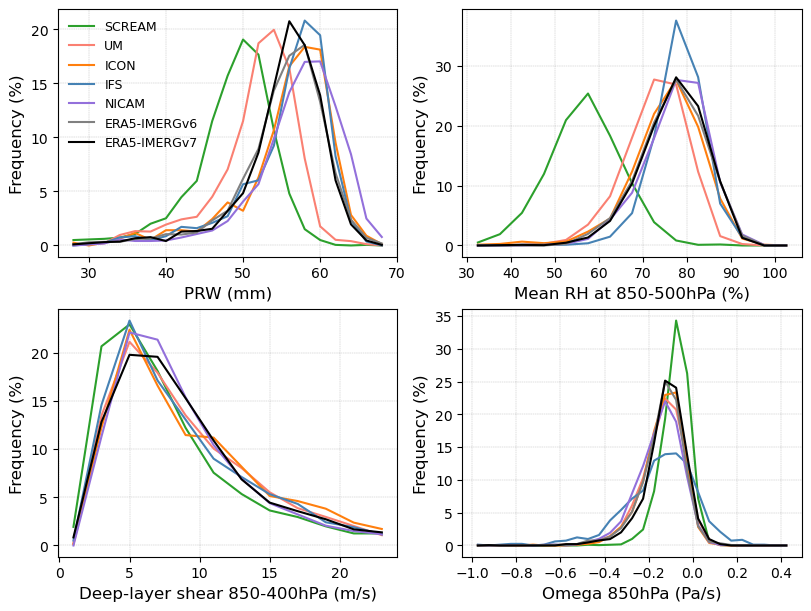

In [29]:
# Select variables to plot
vars_to_plot = ['prw', 'free_rh', 'dShear', 'omega850']

# Create subplots (2x2 grid)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), constrained_layout=True)
axes = axes.flatten() # Flattens the 2x2 grid into a 1D list for easy looping

# --- Outer Loop: Iterate through Variables (Subplots) ---
for ax, var in zip(axes, vars_to_plot):
    
    # Get settings for this variable
    if var not in VAR_SETTINGS:
        print(f"Skipping {var}: No bin settings defined.")
        continue
        
    bins = VAR_SETTINGS[var]['bins']
    mid_bins = 0.5 * (bins[1:] + bins[:-1]) # Calculate x-axis midpoints
    
    # --- Inner Loop: Iterate through Models (Lines) ---
    for model in MODEL_STYLES.keys():
        
        # 1. Retrieve Data
        # Safely get the dataframe from your nested dictionary
        try:
            df = processed_data[model][CRIT][var]
        except KeyError:
            continue # Skip if data doesn't exist for this model
            
        if df is None: continue

        # 2. Filter Data (Radius & Time)
        subset = df[(df.radius == RR) & (df.time_offset_hours == TT)]
        
        if subset.empty:
            continue

        # 3. Calculate Histogram
        # Using numpy vectorization is faster than list comprehension
        counts, _ = np.histogram(subset['mean'].values, bins=bins, density=False)
        
        # Avoid division by zero if sum is 0
        total_counts = counts.sum()
        if total_counts > 0:
            percentages = (counts / total_counts) * 100
        else:
            percentages = np.zeros_like(counts)

        # 4. Plot
        style = MODEL_STYLES[model]
        ax.plot(mid_bins, percentages, 
                color=style['color'], 
                label=style['label'], 
                linewidth=1.5,
                linestyle=style.get('ls', '-')) # Default to solid line

    # --- Subplot Formatting ---
    ax.set_xlabel(VAR_SETTINGS[var]['xlabel'], fontsize=12)
    ax.set_ylabel('Frequency (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('white')
    ax.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.spines['left'].set_color('k'); ax.spines['bottom'].set_color('k')
    ax.spines['left'].set_linewidth(.8); ax.spines['bottom'].set_linewidth(.8)
    
    # Only add legend to the first plot to avoid clutter (or add to all if preferred)
    if var == vars_to_plot[0]:
        ax.legend(fontsize=9, loc='upper left',frameon=False)

# plt.suptitle(f"Distributions at Radius={RR}, Time={TT}h", fontsize=11)

plt.savefig('plots/distribution_4var_init.png', 
            dpi=300, bbox_inches='tight')